# train an agent to play Ms. Pac-Man

**Choose three numbers. Run the notebook. Watch what the agent learns.**

The agent sees the game screen, chooses a move, and receives a reward from the game.
A neural network learns a value for each move through trial and error.

1. Open this notebook in Jupyter, VS Code, or Google Colab. In Colab, select **Runtime → Change runtime type → T4 GPU** if available.
2. Choose your three settings in the next cell.
3. Choose **Run All** (Colab: **Runtime → Run all**). Setup runs automatically. Local gameplay samples open above VS Code in a floating player at **4× speed**; a copy also appears inline.
4. Compare the five before/after scores and save your results.

If using Claude Code or Codex, ask it to run this notebook. The code tells it to ask you for your three choices before training.

A short run checks that everything works. Learning useful Atari behavior can take much longer; more episodes do not guarantee better play.

## 1. your three choices

| Setting | Meaning | Starting point |
|---|---|---|
| **Exploration** | Fraction of training moves chosen randomly. `0.20` means 20%. | `0.20` |
| **Episodes** | How many games to train on. Each game ends at game over or a fixed time limit. | `100` |
| **Learning rate** | How much the network changes at each update. | `0.0001` |

Change only the three numbers below. Try `5` episodes for a first check, then a longer run.
For this experiment, exploration stays **constant** so its meaning is easy to compare across runs.
The short replay warm-up uses random moves before learning starts.

In [ ]:
# Authorized follow-up: fresh 500 episodes, learning-rate decay, new training seed.
# Schedule and seed choices are documented in section 2 and the experiment plan.
EXPLORATION = 0.20
EPISODES = 500
LEARNING_RATE = 0.0001  # Initial rate; decreases at episode boundaries.


### check the choices

These checks catch typos before a long experiment starts. They do not change your settings.

In [ ]:
import math
assert (
    isinstance(EXPLORATION, (int, float))
    and not isinstance(EXPLORATION, bool)
    and math.isfinite(EXPLORATION) and 0 <= EXPLORATION <= 1
), "Exploration must be between 0 and 1."
assert (
    isinstance(EPISODES, int) and not isinstance(EPISODES, bool) and EPISODES > 0
), "Episodes must be a positive whole number."
assert (
    isinstance(LEARNING_RATE, (int, float))
    and not isinstance(LEARNING_RATE, bool)
    and math.isfinite(LEARNING_RATE) and 0 < LEARNING_RATE <= 1
), "Learning rate must be greater than 0 and at most 1."
print(f"Your experiment: {EXPLORATION:.0%} exploration, {EPISODES} episodes, learning rate {LEARNING_RATE:g}.")

Your experiment: 20% exploration, 500 episodes, learning rate 0.0001.


## 2. automatic setup

Run this once per fresh session. It installs missing packages into the notebook's Python environment.
Python 3.11–3.13 is recommended. No separate game download is needed. For local popup playback, keep `pacman_player.py` next to this notebook and use a Python kernel with Tk (the local `py313` kernel supports it). Colab and machines without a desktop keep the fast inline preview.
If a package was already imported before an upgrade, restart the kernel and choose Run All again.

In [ ]:
%pip -q install "torch>=2.6,<3" "gymnasium==1.3.0" "ale-py==0.11.2" "opencv-python-headless==4.14.0.94" "numpy>=2,<3" "matplotlib>=3.9,<4" "Pillow>=10,<13"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 MB 11.0 MB/s eta 0:00:00


### load the tools

Gymnasium runs the game, PyTorch learns from its screens, and Pillow saves gameplay. This cell also prints the actual Python and package versions, so runs can be compared.

In [ ]:
import csv
import json
import platform
import random
import shutil
import time
from collections import deque
from datetime import datetime
from pathlib import Path
from importlib.metadata import version

import ale_py
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from PIL import Image as PILImage
from IPython.display import Image, FileLink, display

gym.register_envs(ale_py)
# Keep CPU thread overhead manageable on laptops.
torch.set_num_threads(min(4, torch.get_num_threads()))


VERSIONS = {p: version(p) for p in ['torch', 'gymnasium', 'ale-py', 'opencv-python-headless', 'numpy', 'matplotlib', 'Pillow']}
print(f"Python {platform.python_version()} | {platform.platform()}")
print(VERSIONS)

Python 3.13.15 | Linux-6.6.122+-x86_64-with-glibc2.39
{'torch': '2.11.0+cu128', 'gymnasium': '1.3.0', 'ale-py': '0.11.2', 'opencv-python-headless': '4.14.0.94', 'numpy': '2.1.3', 'matplotlib': '3.10.0', 'Pillow': '11.3.0'}


### fixed experiment settings

These values keep experiments comparable. One **decision** advances four game frames. The agent remembers 5,000 past decisions and learns from 32 at a time. The first 1,000 decisions collect experience; after that, learning happens every four decisions. You only need to edit the three choices in section 1.
For this authorized follow-up, the training seed is **31415** and the initial
learning rate decays by 20% after each block of 125 episodes. The four rates are
0.0001, 0.00008, 0.000064, and 0.0000512. The original five evaluation seeds stay
unchanged for the classroom comparison; five additional seeds are evaluated
before and after training and reported separately. Neither evaluation set
overlaps the training episode reset seeds 31416 through 31915.


In [ ]:
# Fixed classroom settings. Students only need the three choices above.
SEED = 31415
MAX_STEPS = 3000          # Agent decisions per game, about 200 seconds of game time.
FRAME_SKIP = 4           # Four emulator frames per agent decision, applied once.
REPLAY_CAPACITY = 5000   # About 168 MiB of pixel data, allocated gradually.
BATCH_SIZE = 32
WARMUP_STEPS = 1000      # Random-action collection before any weight updates.
TRAIN_EVERY = 4          # One update every four training decisions.
TARGET_EVERY = 1000      # Copy learned weights to target every 1,000 decisions.
GAMMA = 0.99             # How much future rewards count.
DEMO_EVERY = 25          # Episodes between gameplay demonstrations.
EVAL_SEEDS = [101, 202, 303, 404, 505]
EVAL_EXPLORATION = 0.05  # Identical before/after; independent of training choice.

# Follow-up choices; all other classroom settings above stay unchanged.
LR_DECAY_FACTOR = 0.8
LR_DECAY_EVERY_EPISODES = 125
SUPPLEMENTAL_EVAL_SEEDS = [606, 707, 808, 909, 1010]
assert set(EVAL_SEEDS).isdisjoint(SUPPLEMENTAL_EVAL_SEEDS)
assert all(not SEED < s <= SEED + EPISODES
           for s in EVAL_SEEDS + SUPPLEMENTAL_EVAL_SEEDS)


### faster sample playback

Samples play **4× faster**: 20 seconds of game time takes about five seconds to watch. We save every fourth preview frame and keep a normal display interval, avoiding tiny GIF delays that viewers often clamp. This only changes the recording and playback; every game decision still runs normally.

Local samples open automatically in an **always-on-top popup** with Pause, Replay, and a pin toggle. Each sample plays exactly twice and stops on its final frame. Replay starts two more plays. Closing the popup leaves training running. Set `SHOW_POPUPS = False` for inline playback only.

In [ ]:
PREVIEW_SPEED = 4
PREVIEW_PLAYS = 2
SHOW_POPUPS = True
PREVIEW_SECONDS = 20
PREVIEW_STRIDE = PREVIEW_SPEED
PREVIEW_DECISIONS = round(PREVIEW_SECONDS * 60 / FRAME_SKIP)
PREVIEW_FRAME_MS = round(1000 * FRAME_SKIP / 60)

## 3. the game and the learning rule

The network sees **four grayscale 84 × 84 screens** so it can infer movement.
Its outputs are estimated future rewards for the available moves, not probabilities.

The agent keeps past experiences in a small replay memory. It samples them to update the network.
A second, slower-changing network supplies the learning target:

**target = reward + discounted value of the next screen**

At game over, there is no future reward. At a time limit, the game could have continued, so we keep the future-value term.
Learning uses rewards clipped to −1 through +1; every score you see is the **original game score**.
The implementation below is ready to use. You do not need to edit it.

### 3a. turn game screens into observations

Start Ms. Pac-Man, reduce each screen to 84 × 84 grayscale pixels, and stack four screens. A single image shows position; a short sequence also reveals movement. Reset starts with four copies of the new game screen.

In [ ]:
def make_env():
    env = gym.make("ALE/MsPacman-v5", frameskip=1,
                   repeat_action_probability=0.25, render_mode="rgb_array")
    env = gym.wrappers.AtariPreprocessing(
        env, noop_max=30, frame_skip=FRAME_SKIP, screen_size=84,
        terminal_on_life_loss=False, grayscale_obs=True, scale_obs=False)
    env = gym.wrappers.FrameStackObservation(env, stack_size=4, padding_type="reset")
    return gym.wrappers.TimeLimit(env, max_episode_steps=MAX_STEPS)

### 3b. estimate the value of each move

The convolution layers look for patterns in the screens. The final layer produces one number per move: its estimated future reward. `forward` scales pixel values from 0–255 to 0–1 before using them.

In [ ]:
class DQN(nn.Module):
    def __init__(self, n_actions):
        super().__init__()
        # Read visual patterns, then produce one value per available move.
        self.layers = nn.Sequential(
            nn.Conv2d(4, 32, 8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1), nn.ReLU(),
            nn.Flatten(), nn.Linear(3136, 512), nn.ReLU(),
            nn.Linear(512, n_actions))

    def forward(self, screens):
        return self.layers(screens.float() / 255.0)

### 3c. remember past experience

Each memory stores the screen stack, move, reward, next screen, and whether the game ended. Random batches mix experiences from different moments. Consecutive stacks share three frames, so we only store the one new frame to save memory.

In [ ]:
class ReplayMemory:
    def __init__(self, capacity):
        self.items = deque(maxlen=capacity)

    def add(self, obs, action, reward, next_obs, terminated, truncated):
        # The next stack is [obs[1], obs[2], obs[3], new_frame].
        # Store five frames instead of two overlapping four-frame stacks.
        self.items.append((np.array(obs, dtype=np.uint8, copy=True), action,
                           float(np.clip(reward, -1, 1)),
                           np.array(next_obs[-1], dtype=np.uint8, copy=True),
                           bool(terminated), bool(truncated)))

    def sample(self, size, rng):
        batch = rng.sample(list(self.items), size)
        obs, actions, rewards, last_frames, ended, truncated = zip(*batch)
        obs = np.stack(obs)
        next_obs = np.concatenate([obs[:, 1:], np.stack(last_frames)[:, None]], axis=1)
        return obs, np.array(actions), np.array(rewards, dtype=np.float32), next_obs, np.array(ended), np.array(truncated)

    def __len__(self):
        return len(self.items)

### 3d. choose a move

With probability `epsilon`, try a random move (**explore**). Otherwise choose the move with the highest predicted value (**exploit**). Choosing a move does not update the network.

In [ ]:
@torch.no_grad()
def choose_action(model, obs, epsilon, rng, n_actions):
    if rng.random() < epsilon:
        return rng.randrange(n_actions)
    device = next(model.parameters()).device
    screens = torch.as_tensor(np.asarray(obs), device=device).unsqueeze(0)
    return int(model(screens).argmax(dim=1).item())

### 3e. learn from a batch

1. Predict the value of each remembered move.
2. Build a target from its reward plus the next screen’s estimated value.
3. Measure the prediction error and adjust the network.

The target network changes less often to give learning a steadier reference. True game over removes future reward; reaching the time limit does not.

In [ ]:
def learn(model, target, optimizer, batch):
    device = next(model.parameters()).device
    obs, actions, rewards, next_obs, ended, truncated = [torch.as_tensor(x, device=device) for x in batch]
    # 1. What value did the network predict for the move we took?
    values = model(obs).gather(1, actions.long().unsqueeze(1)).squeeze(1)
    # 2. What target does the observed reward suggest?
    with torch.no_grad():
        # Mask true termination only. A time limit still allows bootstrapping.
        targets = rewards + GAMMA * (~ended).float() * target(next_obs).max(dim=1).values
    # 3. Reduce the gap between prediction and target.
    loss = nn.functional.smooth_l1_loss(values, targets)
    if not torch.isfinite(loss):
        raise RuntimeError("Loss became non-finite. Start a new run with a smaller learning rate.")
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 10.0, error_if_nonfinite=True)
    optimizer.step()
    return float(loss.item())

### 3f. select working hardware

Try CUDA, Apple MPS, then CPU. A real batch tests prediction, backward pass, and a weight update before we commit to that device.

In [ ]:
def select_device(n_actions):
    candidates = []
    if torch.cuda.is_available():
        candidates.append("cuda")
    if torch.backends.mps.is_available():
        candidates.append("mps")
    candidates.append("cpu")
    for candidate in candidates:
        try:
            # Test the actual network, minibatch, backward pass, and optimizer.
            probe = DQN(n_actions).to(candidate)
            optimizer = torch.optim.Adam(probe.parameters(), lr=LEARNING_RATE)
            screens = np.zeros((BATCH_SIZE, 4, 84, 84), dtype=np.uint8)
            batch = (screens, np.zeros(BATCH_SIZE, dtype=np.int64),
                     np.ones(BATCH_SIZE, dtype=np.float32), screens,
                     np.zeros(BATCH_SIZE, dtype=bool), np.zeros(BATCH_SIZE, dtype=bool))
            learn(probe, probe, optimizer, batch)
            print(f"Using {candidate.upper()}; training-batch check passed.")
            return torch.device(candidate)
        except RuntimeError as error:
            if candidate == "cpu":
                raise
            print(f"{candidate.upper()} check failed ({error}). Trying the next device.")

### check the first screen

Create the game, check the four-screen stack, and show the available joystick moves. If this cell succeeds, the game and learning hardware are ready.

Using CUDA; training-batch check passed.
Available moves: ['NOOP', 'UP', 'RIGHT', 'LEFT', 'DOWN', 'UPRIGHT', 'UPLEFT', 'DOWNRIGHT', 'DOWNLEFT']


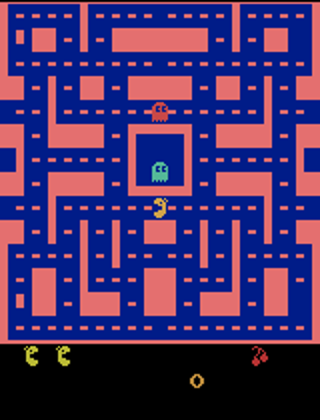

Replay pixel budget: 168 MiB, plus model and batch memory.


In [ ]:
probe_env = make_env()
try:
    probe_obs, _ = probe_env.reset(seed=SEED)
    assert probe_obs.shape == (4, 84, 84) and probe_obs.dtype == np.uint8
    assert all(np.array_equal(probe_obs[0], frame) for frame in probe_obs)
    N_ACTIONS = int(probe_env.action_space.n)
    DEVICE = select_device(N_ACTIONS)
    print("Available moves:", probe_env.unwrapped.get_action_meanings())
    display(PILImage.fromarray(probe_env.render()).resize((320, 420)))
finally:
    probe_env.close()
print(f"Replay pixel budget: {REPLAY_CAPACITY * 5 * 84 * 84 / 2**20:.0f} MiB, plus model and batch memory.")

## 4. gameplay, scores, and saved results

Evaluation uses a separate game environment and the same five seeds before and after training.
It uses 5% random moves in both cases. Evaluation never changes the network or training memory.
The baseline is an **untrained network**, not a random-action agent.

GIFs show the first 20 seconds at most, compressed to about five seconds at 4× speed; the reported score covers the entire evaluated game, up to the fixed time limit.

### 4a. score complete games and record a short sample

All evaluation games run at full computing speed, with no waiting for playback. We record a short excerpt, but add rewards for the **entire game**. For the final preview we keep the excerpt from the game with the highest full-game score.

In [ ]:
def evaluate(model, seeds, gif_path=None, record_best=False):
    env = make_env()
    scores, lengths, capped = [], [], []
    best_score, chosen_frames = -float("inf"), []
    was_training = model.training
    model.eval()
    try:
        for index, seed in enumerate(seeds):
            rng = random.Random(seed + 10000)
            obs, _ = env.reset(seed=seed)
            total, frames = 0.0, []
            capture = gif_path is not None and (record_best or index == 0)
            for step in range(MAX_STEPS):
                if capture and step < PREVIEW_DECISIONS and step % PREVIEW_STRIDE == 0:
                    frames.append(PILImage.fromarray(env.render()).copy())
                action = choose_action(model, obs, EVAL_EXPLORATION, rng, N_ACTIONS)
                obs, reward, ended, truncated, _ = env.step(action)
                total += reward
                if ended or truncated:
                    break
            scores.append(float(total))
            lengths.append(step + 1)
            capped.append(bool(truncated))
            if capture and (not record_best or total > best_score):
                chosen_frames, best_score = frames, total
    finally:
        env.close()
        model.train(was_training)
    if gif_path is not None and chosen_frames:
        chosen_frames[0].save(gif_path, save_all=True, append_images=chosen_frames[1:],
                              duration=PREVIEW_FRAME_MS, loop=PREVIEW_PLAYS - 1)
    return {"seeds": list(seeds), "scores": scores, "mean": float(np.mean(scores)),
            "steps": lengths, "time_limited": capped}

### 4b. show the sample

Always keep a playable GIF in the notebook. Both the inline GIF and the popup play exactly twice. When a local desktop and Tk are available, the separate floating player does not block the next learning update.

In [ ]:
def show_sample(gif_path, label):
    """Display a recorded excerpt inline and, locally, above the notebook."""
    print(f"{label} | {PREVIEW_SPEED}× playback | {PREVIEW_PLAYS} plays | first {PREVIEW_SECONDS}s of game time")
    display(Image(filename=str(gif_path)))
    if not SHOW_POPUPS:
        return
    try:
        from pacman_player import show_popup
        opened = show_popup(gif_path, f"{label} · {PREVIEW_SPEED}× speed")
        if not opened:
            print("Popup unavailable in this kernel; use the fast inline preview.")
    except (ImportError, OSError) as error:
        print(f"Using the inline preview. Local popup helper unavailable: {error}")

### 4c. save a model for playback

A checkpoint stores the learned weights and action count. Reloading it lets us check the saved agent. It does not contain everything needed to resume the exact training session.

In [ ]:
def save_checkpoint(model, path, episode, steps):
    # Portable playback checkpoint. This is not an exact training-resume snapshot:
    # replay, optimizer, and emulator state are intentionally not persisted.
    payload = {"model": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
               "n_actions": N_ACTIONS, "episode": episode, "steps": steps,
               "exploration": EXPLORATION, "learning_rate": float(optimizer.param_groups[0]["lr"]),
               "initial_learning_rate": LEARNING_RATE, "seed": SEED}
    temporary = path.with_suffix(".tmp")
    torch.save(payload, temporary)
    temporary.replace(path)

### 4d. save one row per game

The CSV keeps each completed game’s raw score, decisions, exploration, loss, and elapsed time. A game with no learning updates has no meaningful loss yet.

In [ ]:
def save_metrics(rows, path):
    fields = ["episode", "score", "steps", "total_steps", "exploration", "mean_loss", "elapsed_seconds", "terminated", "truncated", "learning_rate"]
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fields)
        writer.writeheader()
        writer.writerows(rows)

### 4e. draw the learning dashboard

The three panels show scores, prediction error, and exploration. Look at game scores as well as loss: reducing prediction error does not guarantee better play.

In [ ]:
def plot_training(rows, path):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    if rows:
        episodes = [r["episode"] for r in rows]
        scores = [r["score"] for r in rows]
        smooth = [np.mean(scores[max(0, i - 24):i + 1]) for i in range(len(scores))]
        axes[0].plot(episodes, scores, alpha=0.35, label="Each training game")
        axes[0].plot(episodes, smooth, label="Up to 25-game average")
        axes[0].legend(fontsize=8)
        axes[1].plot(episodes, [r["mean_loss"] for r in rows])
        axes[2].plot(episodes, [r["exploration"] for r in rows])
    for ax, title in zip(axes, ["Raw training score", "Mean update loss", "Training exploration"]):
        ax.set(title=title, xlabel="Completed episode")
        ax.grid(alpha=0.2)
    axes[2].set_ylim(0, 1.05)
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.close(fig)

## 5. train your agent

The setup cell below starts a **fresh experiment** each time, using your three choices.
It saves the untrained baseline, trains, and prints a line after each episode plus a progress update every 500 decisions.
Every 25 episodes it opens a fast gameplay sample and saves a checkpoint and plot.

To stop early, use the notebook's **Interrupt / Stop** button once. The current model and completed-episode results are saved.
Then run the remaining cells to evaluate and download them. A run ending before warm-up finishes has no learning updates yet.
Each run has its own folder so earlier experiments stay available.

### 5a. start a fresh experiment

Create the two networks, empty replay memory, random seeds, and a unique results folder. This cell resets training. To try again, rerun from here or choose Run All.

In [ ]:
# Each execution starts fresh, including network weights and replay memory.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
train_rng = random.Random(SEED)
replay_rng = random.Random(SEED + 1)
RUN_DIR = Path("pacman_runs") / datetime.now().strftime("%Y%m%d_%H%M%S_%f")
RUN_DIR.mkdir(parents=True, exist_ok=False)
(RUN_DIR / "demos").mkdir()
model = DQN(N_ACTIONS).to(DEVICE)
target = DQN(N_ACTIONS).to(DEVICE)
target.load_state_dict(model.state_dict())
target.eval()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
replay = ReplayMemory(REPLAY_CAPACITY)
history, demo_history = [], []
total_steps, completed_episodes, updates = 0, 0, 0

_training_started = False

### 5b. record the settings and test saving

Save the hardware and settings alongside the initial weights. Reload those weights immediately to catch any checkpoint problem before training.

In [ ]:
config = {"exploration": EXPLORATION, "episodes_requested": EPISODES, "learning_rate": LEARNING_RATE,
          "seed": SEED, "device": str(DEVICE), "python": platform.python_version(),
          "platform": platform.platform(), "packages": VERSIONS,
          "environment": "ALE/MsPacman-v5", "frame_skip": FRAME_SKIP,
          "sticky_action_probability": 0.25, "noop_max": 30, "grayscale_size": 84,
          "stack_size": 4, "terminal_on_life_loss": False, "max_decisions_per_game": MAX_STEPS,
          "replay_capacity": REPLAY_CAPACITY, "warmup_decisions": WARMUP_STEPS,
          "batch_size": BATCH_SIZE, "train_every_decisions": TRAIN_EVERY,
          "target_sync_decisions": TARGET_EVERY, "gamma": GAMMA,
          "training_reward_clipping": [-1, 1], "eval_exploration": EVAL_EXPLORATION,
          "eval_seeds": EVAL_SEEDS, "preview_seconds": PREVIEW_SECONDS,
          "preview_speed": PREVIEW_SPEED, "preview_plays": PREVIEW_PLAYS,
          "preview_stride": PREVIEW_STRIDE,
          "preview_frame_ms": PREVIEW_FRAME_MS}
config.update({
    "learning_rate_schedule": {
        "kind": "episode_step_decay", "factor": LR_DECAY_FACTOR,
        "every_completed_episodes": LR_DECAY_EVERY_EPISODES,
        "rates_by_episode_block": [
            {"first_episode": first, "last_episode": min(first + LR_DECAY_EVERY_EPISODES - 1, EPISODES),
             "learning_rate": LEARNING_RATE * LR_DECAY_FACTOR ** ((first - 1) // LR_DECAY_EVERY_EPISODES)}
            for first in range(1, EPISODES + 1, LR_DECAY_EVERY_EPISODES)
        ]
    },
    "supplemental_eval_seeds": SUPPLEMENTAL_EVAL_SEEDS,
    "experiment_note": "Fresh 500 episodes; changed training seed and learning-rate schedule. Multi-change experiment, not an isolated episode-budget test."
})
(RUN_DIR / "config.json").write_text(json.dumps(config, indent=2))
save_checkpoint(model, RUN_DIR / "untrained.pt", 0, 0)
# Check saving and loading before starting the long run.
roundtrip = torch.load(RUN_DIR / "untrained.pt", map_location="cpu", weights_only=True)
assert all(torch.equal(v.cpu(), roundtrip["model"][k]) for k, v in model.state_dict().items())
del roundtrip

### 5c. measure the starting point

Play five games before learning. This gives a baseline for the final comparison. The popup shows a short, accelerated excerpt from the first game.

Evaluating the untrained network on five games. This can take a few minutes.
Before training: [200.0, 240.0, 240.0, 240.0, 170.0] | mean: 218.0
Before training | 4× playback | 2 plays | first 20s of game time


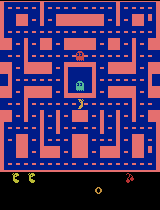

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
Evaluating the untrained network on supplemental seeds...
Supplemental before: [240.0, 230.0, 300.0, 240.0, 250.0] | mean: 252.0


In [ ]:
print("Evaluating the untrained network on five games. This can take a few minutes.", flush=True)
baseline = evaluate(model, EVAL_SEEDS, RUN_DIR / "demos" / "episode_0000.gif")
(RUN_DIR / "baseline.json").write_text(json.dumps(baseline, indent=2))
print("Before training:", baseline["scores"], "| mean:", baseline["mean"])
show_sample(RUN_DIR / "demos" / "episode_0000.gif", "Before training")
print("Evaluating the untrained network on supplemental seeds...", flush=True)
supplemental_baseline = evaluate(model, SUPPLEMENTAL_EVAL_SEEDS)
(RUN_DIR / "supplemental_baseline.json").write_text(json.dumps(supplemental_baseline, indent=2))
print("Supplemental before:", supplemental_baseline["scores"], "| mean:", supplemental_baseline["mean"])


### 5d. learn during one game

Repeat **choose → play → remember → learn** until game over or the time limit. The counters span all games, so warm-up happens once. Every 1,000 decisions, copy the learning network into the target network.

In [ ]:
def train_one_episode(train_env, episode):
    """Collect experience and update the agent during one complete game."""
    global total_steps, updates
    # Episode 126, 251, and 376 start the next lower-rate block.
    current_lr = LEARNING_RATE * LR_DECAY_FACTOR ** ((episode - 1) // LR_DECAY_EVERY_EPISODES)
    for group in optimizer.param_groups:
        group["lr"] = current_lr
    obs, _ = train_env.reset(seed=SEED + episode)
    score, losses = 0.0, []
    for step in range(MAX_STEPS):
        epsilon = 1.0 if total_steps < WARMUP_STEPS else EXPLORATION
        action = choose_action(model, obs, epsilon, train_rng, N_ACTIONS)
        next_obs, reward, ended, truncated, _ = train_env.step(action)
        replay.add(obs, action, reward, next_obs, ended, truncated)
        obs = next_obs
        score += reward
        total_steps += 1
        if total_steps >= WARMUP_STEPS and len(replay) >= BATCH_SIZE and total_steps % TRAIN_EVERY == 0:
            losses.append(learn(model, target, optimizer, replay.sample(BATCH_SIZE, replay_rng)))
            updates += 1
        if total_steps % TARGET_EVERY == 0:
            target.load_state_dict(model.state_dict())
        if total_steps % 500 == 0:
            elapsed = time.monotonic() - started
            print(f"  Episode {episode}/{EPISODES} | {total_steps:,} decisions | {updates:,} updates | {elapsed / 60:.1f} min", flush=True)
        if ended or truncated:
            break
    return {"episode": episode, "score": float(score), "steps": step + 1,
            "total_steps": total_steps, "exploration": epsilon,
            "mean_loss": float(np.mean(losses)) if losses else float("nan"),
            "elapsed_seconds": time.monotonic() - started,
            "terminated": bool(ended), "truncated": bool(truncated),
            "learning_rate": float(current_lr)}

### 5e. save a progress sample

Every 25 completed games, evaluate on a separate game, show the fast popup, and save a checkpoint. Evaluation does not add experiences to replay or change weights.

In [ ]:
def save_progress_sample(episode):
    gif_path = RUN_DIR / "demos" / f"episode_{episode:04d}.gif"
    demo = evaluate(model, EVAL_SEEDS[:1], gif_path)
    demo_history.append({"episode": episode, **demo})
    (RUN_DIR / "demo_scores.json").write_text(json.dumps(demo_history, indent=2))
    print("Separate demonstration score:", demo["scores"][0])
    save_checkpoint(model, RUN_DIR / f"episode_{episode:04d}.pt", episode, total_steps)
    plot_training(history, RUN_DIR / "training_dashboard.png")
    show_sample(gif_path, f"After {episode} training games")

### 5f. save the current result

Run this helper on completion, interruption, or failure. Checkpoints include all weight updates so far; the CSV contains completed games only.

In [ ]:
def save_training_result(status):
    save_checkpoint(model, RUN_DIR / "trained.pt", completed_episodes, total_steps)
    save_metrics(history, RUN_DIR / "training.csv")
    plot_training(history, RUN_DIR / "training_dashboard.png")
    summary = {"status": status, "completed_episodes": completed_episodes,
               "total_decisions": total_steps, "learning_updates": updates,
               "initial_learning_rate": LEARNING_RATE,
               "final_learning_rate": float(optimizer.param_groups[0]["lr"]),
               "elapsed_seconds_including_periodic_demos": time.monotonic() - started}
    (RUN_DIR / "training_summary.json").write_text(json.dumps(summary, indent=2))

### 5g. run the training games

This is the experiment loop. Each call plays one game and prints its score. **Interrupt / Stop** saves the current model; then continue to section 6. To start another experiment, rerun from 5a so the model, baseline, and results folder all reset together.

Episode 1/500 | score 170 | recent mean 170.0 | exploration 100% | learning rate 0.00010000
  Episode 2/500 | 500 decisions | 0 updates | 0.0 min
Episode 2/500 | score 200 | recent mean 185.0 | exploration 100% | learning rate 0.00010000
  Episode 3/500 | 1,000 decisions | 1 updates | 0.0 min
  Episode 3/500 | 1,500 decisions | 126 updates | 0.1 min
Episode 3/500 | score 760 | recent mean 376.7 | exploration 20% | learning rate 0.00010000
  Episode 4/500 | 2,000 decisions | 251 updates | 0.1 min
Episode 4/500 | score 570 | recent mean 425.0 | exploration 20% | learning rate 0.00010000
  Episode 5/500 | 2,500 decisions | 376 updates | 0.1 min
Episode 5/500 | score 1010 | recent mean 542.0 | exploration 20% | learning rate 0.00010000
  Episode 6/500 | 3,000 decisions | 501 updates | 0.2 min
  Episode 6/500 | 3,500 decisions | 626 updates | 0.2 min
Episode 6/500 | score 670 | recent mean 563.3 | exploration 20% | learning rate 0.00010000
  Episode 7/500 | 4,000 decisions | 751 updates | 0

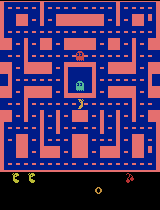

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 26/500 | 15,000 decisions | 3,501 updates | 1.0 min
  Episode 26/500 | 15,500 decisions | 3,626 updates | 1.0 min
Episode 26/500 | score 490 | recent mean 596.8 | exploration 20% | learning rate 0.00010000
  Episode 27/500 | 16,000 decisions | 3,751 updates | 1.0 min
Episode 27/500 | score 520 | recent mean 609.6 | exploration 20% | learning rate 0.00010000
  Episode 28/500 | 16,500 decisions | 3,876 updates | 1.1 min
Episode 28/500 | score 380 | recent mean 594.4 | exploration 20% | learning rate 0.00010000
  Episode 29/500 | 17,000 decisions | 4,001 updates | 1.1 min
Episode 29/500 | score 240 | recent mean 581.2 | exploration 20% | learning rate 0.00010000
Episode 30/500 | score 350 | recent mean 554.8 | exploration 20% | learning rate 0.00010000
  Episode 31/500 | 17,500 decisions | 4,126 updates | 1.1 min
Episode 31/500 | score 320 | recent mean 540.8 | exploration 20% | learning ra

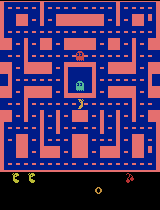

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 51/500 | 28,000 decisions | 6,751 updates | 1.8 min
Episode 51/500 | score 620 | recent mean 536.4 | exploration 20% | learning rate 0.00010000
  Episode 52/500 | 28,500 decisions | 6,876 updates | 1.9 min
  Episode 52/500 | 29,000 decisions | 7,001 updates | 1.9 min
Episode 52/500 | score 1530 | recent mean 576.8 | exploration 20% | learning rate 0.00010000
  Episode 53/500 | 29,500 decisions | 7,126 updates | 1.9 min
Episode 53/500 | score 390 | recent mean 577.2 | exploration 20% | learning rate 0.00010000
  Episode 54/500 | 30,000 decisions | 7,251 updates | 1.9 min
  Episode 54/500 | 30,500 decisions | 7,376 updates | 2.0 min
Episode 54/500 | score 1310 | recent mean 620.0 | exploration 20% | learning rate 0.00010000
  Episode 55/500 | 31,000 decisions | 7,501 updates | 2.0 min
Episode 55/500 | score 820 | recent mean 638.8 | exploration 20% | learning rate 0.00010000
  Episode 56/5

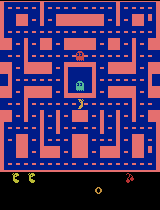

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 76/500 | 43,500 decisions | 10,626 updates | 2.8 min
Episode 76/500 | score 650 | recent mean 694.0 | exploration 20% | learning rate 0.00010000
  Episode 77/500 | 44,000 decisions | 10,751 updates | 2.8 min
  Episode 77/500 | 44,500 decisions | 10,876 updates | 2.9 min
Episode 77/500 | score 730 | recent mean 662.0 | exploration 20% | learning rate 0.00010000
  Episode 78/500 | 45,000 decisions | 11,001 updates | 2.9 min
Episode 78/500 | score 430 | recent mean 663.6 | exploration 20% | learning rate 0.00010000
  Episode 79/500 | 45,500 decisions | 11,126 updates | 2.9 min
Episode 79/500 | score 220 | recent mean 620.0 | exploration 20% | learning rate 0.00010000
  Episode 80/500 | 46,000 decisions | 11,251 updates | 3.0 min
Episode 80/500 | score 1020 | recent mean 628.0 | exploration 20% | learning rate 0.00010000
  Episode 81/500 | 46,500 decisions | 11,376 updates | 3.0 min
Episode 

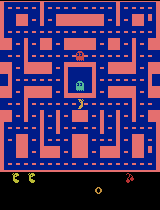

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 101/500 | 60,500 decisions | 14,876 updates | 3.9 min
  Episode 101/500 | 61,000 decisions | 15,001 updates | 3.9 min
Episode 101/500 | score 640 | recent mean 760.4 | exploration 20% | learning rate 0.00010000
  Episode 102/500 | 61,500 decisions | 15,126 updates | 4.0 min
Episode 102/500 | score 890 | recent mean 766.8 | exploration 20% | learning rate 0.00010000
  Episode 103/500 | 62,000 decisions | 15,251 updates | 4.0 min
Episode 103/500 | score 390 | recent mean 765.2 | exploration 20% | learning rate 0.00010000
  Episode 104/500 | 62,500 decisions | 15,376 updates | 4.0 min
  Episode 104/500 | 63,000 decisions | 15,501 updates | 4.0 min
Episode 104/500 | score 980 | recent mean 795.6 | exploration 20% | learning rate 0.00010000
  Episode 105/500 | 63,500 decisions | 15,626 updates | 4.1 min
Episode 105/500 | score 740 | recent mean 784.4 | exploration 20% | learning rate 0.000100

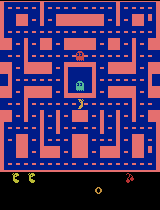

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 126/500 | 75,000 decisions | 18,501 updates | 4.8 min
Episode 126/500 | score 570 | recent mean 597.6 | exploration 20% | learning rate 0.00008000
  Episode 127/500 | 75,500 decisions | 18,626 updates | 4.9 min
Episode 127/500 | score 370 | recent mean 576.8 | exploration 20% | learning rate 0.00008000
  Episode 128/500 | 76,000 decisions | 18,751 updates | 4.9 min
  Episode 128/500 | 76,500 decisions | 18,876 updates | 4.9 min
Episode 128/500 | score 770 | recent mean 592.0 | exploration 20% | learning rate 0.00008000
Episode 129/500 | score 310 | recent mean 565.2 | exploration 20% | learning rate 0.00008000
  Episode 130/500 | 77,000 decisions | 19,001 updates | 5.0 min
  Episode 130/500 | 77,500 decisions | 19,126 updates | 5.0 min
Episode 130/500 | score 970 | recent mean 574.4 | exploration 20% | learning rate 0.00008000
  Episode 131/500 | 78,000 decisions | 19,251 updates | 5.0 m

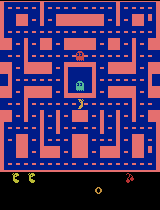

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 151/500 | 89,000 decisions | 22,001 updates | 5.8 min
Episode 151/500 | score 460 | recent mean 632.0 | exploration 20% | learning rate 0.00008000
  Episode 152/500 | 89,500 decisions | 22,126 updates | 5.8 min
Episode 152/500 | score 990 | recent mean 656.8 | exploration 20% | learning rate 0.00008000
  Episode 153/500 | 90,000 decisions | 22,251 updates | 5.8 min
Episode 153/500 | score 640 | recent mean 651.6 | exploration 20% | learning rate 0.00008000
  Episode 154/500 | 90,500 decisions | 22,376 updates | 5.9 min
  Episode 154/500 | 91,000 decisions | 22,501 updates | 5.9 min
Episode 154/500 | score 680 | recent mean 666.4 | exploration 20% | learning rate 0.00008000
  Episode 155/500 | 91,500 decisions | 22,626 updates | 5.9 min
Episode 155/500 | score 410 | recent mean 644.0 | exploration 20% | learning rate 0.00008000
  Episode 156/500 | 92,000 decisions | 22,751 updates | 5.9 m

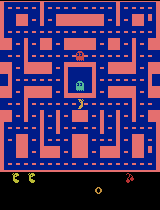

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 176/500 | 104,500 decisions | 25,876 updates | 6.8 min
Episode 176/500 | score 260 | recent mean 763.2 | exploration 20% | learning rate 0.00008000
  Episode 177/500 | 105,000 decisions | 26,001 updates | 6.8 min
Episode 177/500 | score 530 | recent mean 744.8 | exploration 20% | learning rate 0.00008000
  Episode 178/500 | 105,500 decisions | 26,126 updates | 6.8 min
Episode 178/500 | score 480 | recent mean 738.4 | exploration 20% | learning rate 0.00008000
  Episode 179/500 | 106,000 decisions | 26,251 updates | 6.9 min
  Episode 179/500 | 106,500 decisions | 26,376 updates | 6.9 min
Episode 179/500 | score 680 | recent mean 738.4 | exploration 20% | learning rate 0.00008000
Episode 180/500 | score 400 | recent mean 738.0 | exploration 20% | learning rate 0.00008000
  Episode 181/500 | 107,000 decisions | 26,501 updates | 6.9 min
Episode 181/500 | score 440 | recent mean 728.8 | explo

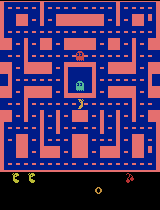

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
Episode 201/500 | score 320 | recent mean 646.4 | exploration 20% | learning rate 0.00008000
  Episode 202/500 | 119,500 decisions | 29,626 updates | 7.8 min
  Episode 202/500 | 120,000 decisions | 29,751 updates | 7.8 min
Episode 202/500 | score 1830 | recent mean 698.4 | exploration 20% | learning rate 0.00008000
  Episode 203/500 | 120,500 decisions | 29,876 updates | 7.8 min
Episode 203/500 | score 500 | recent mean 699.2 | exploration 20% | learning rate 0.00008000
  Episode 204/500 | 121,000 decisions | 30,001 updates | 7.9 min
Episode 204/500 | score 670 | recent mean 698.8 | exploration 20% | learning rate 0.00008000
  Episode 205/500 | 121,500 decisions | 30,126 updates | 7.9 min
  Episode 205/500 | 122,000 decisions | 30,251 updates | 7.9 min
Episode 205/500 | score 660 | recent mean 709.2 | exploration 20% | learning rate 0.00008000
  Episode 206/500 | 122,500 decisions | 30,376 updates

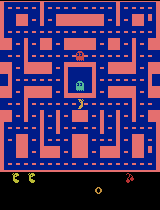

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 226/500 | 133,500 decisions | 33,126 updates | 8.7 min
  Episode 226/500 | 134,000 decisions | 33,251 updates | 8.7 min
Episode 226/500 | score 1190 | recent mean 711.6 | exploration 20% | learning rate 0.00008000
  Episode 227/500 | 134,500 decisions | 33,376 updates | 8.8 min
Episode 227/500 | score 670 | recent mean 665.2 | exploration 20% | learning rate 0.00008000
  Episode 228/500 | 135,000 decisions | 33,501 updates | 8.8 min
Episode 228/500 | score 690 | recent mean 672.8 | exploration 20% | learning rate 0.00008000
  Episode 229/500 | 135,500 decisions | 33,626 updates | 8.8 min
  Episode 229/500 | 136,000 decisions | 33,751 updates | 8.9 min
Episode 229/500 | score 840 | recent mean 679.6 | exploration 20% | learning rate 0.00008000
  Episode 230/500 | 136,500 decisions | 33,876 updates | 8.9 min
  Episode 230/500 | 137,000 decisions | 34,001 updates | 8.9 min
Episode 230/500 |

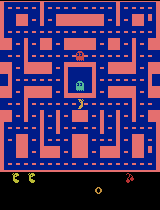

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 251/500 | 148,500 decisions | 36,876 updates | 9.7 min
Episode 251/500 | score 470 | recent mean 672.8 | exploration 20% | learning rate 0.00006400
  Episode 252/500 | 149,000 decisions | 37,001 updates | 9.7 min
Episode 252/500 | score 390 | recent mean 661.6 | exploration 20% | learning rate 0.00006400
  Episode 253/500 | 149,500 decisions | 37,126 updates | 9.8 min
Episode 253/500 | score 360 | recent mean 648.4 | exploration 20% | learning rate 0.00006400
  Episode 254/500 | 150,000 decisions | 37,251 updates | 9.8 min
Episode 254/500 | score 1280 | recent mean 666.0 | exploration 20% | learning rate 0.00006400
  Episode 255/500 | 150,500 decisions | 37,376 updates | 9.8 min
Episode 255/500 | score 260 | recent mean 587.6 | exploration 20% | learning rate 0.00006400
  Episode 256/500 | 151,000 decisions | 37,501 updates | 9.9 min
Episode 256/500 | score 420 | recent mean 577.6 | expl

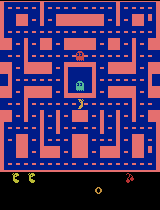

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 276/500 | 162,000 decisions | 40,251 updates | 10.6 min
Episode 276/500 | score 420 | recent mean 645.6 | exploration 20% | learning rate 0.00006400
  Episode 277/500 | 162,500 decisions | 40,376 updates | 10.6 min
Episode 277/500 | score 460 | recent mean 648.4 | exploration 20% | learning rate 0.00006400
  Episode 278/500 | 163,000 decisions | 40,501 updates | 10.7 min
Episode 278/500 | score 620 | recent mean 658.8 | exploration 20% | learning rate 0.00006400
  Episode 279/500 | 163,500 decisions | 40,626 updates | 10.7 min
Episode 279/500 | score 410 | recent mean 624.0 | exploration 20% | learning rate 0.00006400
  Episode 280/500 | 164,000 decisions | 40,751 updates | 10.7 min
Episode 280/500 | score 420 | recent mean 630.4 | exploration 20% | learning rate 0.00006400
  Episode 281/500 | 164,500 decisions | 40,876 updates | 10.8 min
Episode 281/500 | score 410 | recent mean 630.0 |

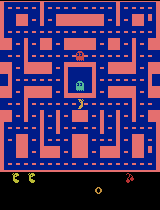

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 301/500 | 177,000 decisions | 44,001 updates | 11.6 min
Episode 301/500 | score 190 | recent mean 626.4 | exploration 20% | learning rate 0.00006400
  Episode 302/500 | 177,500 decisions | 44,126 updates | 11.6 min
Episode 302/500 | score 520 | recent mean 628.8 | exploration 20% | learning rate 0.00006400
  Episode 303/500 | 178,000 decisions | 44,251 updates | 11.6 min
Episode 303/500 | score 450 | recent mean 622.0 | exploration 20% | learning rate 0.00006400
  Episode 304/500 | 178,500 decisions | 44,376 updates | 11.7 min
Episode 304/500 | score 330 | recent mean 618.8 | exploration 20% | learning rate 0.00006400
  Episode 305/500 | 179,000 decisions | 44,501 updates | 11.7 min
Episode 305/500 | score 480 | recent mean 621.2 | exploration 20% | learning rate 0.00006400
  Episode 306/500 | 179,500 decisions | 44,626 updates | 11.7 min
Episode 306/500 | score 760 | recent mean 635.2 |

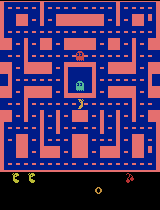

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 326/500 | 191,500 decisions | 47,626 updates | 12.5 min
  Episode 326/500 | 192,000 decisions | 47,751 updates | 12.6 min
Episode 326/500 | score 510 | recent mean 653.6 | exploration 20% | learning rate 0.00006400
  Episode 327/500 | 192,500 decisions | 47,876 updates | 12.6 min
  Episode 327/500 | 193,000 decisions | 48,001 updates | 12.6 min
Episode 327/500 | score 1450 | recent mean 690.8 | exploration 20% | learning rate 0.00006400
  Episode 328/500 | 193,500 decisions | 48,126 updates | 12.7 min
Episode 328/500 | score 770 | recent mean 703.6 | exploration 20% | learning rate 0.00006400
Episode 329/500 | score 180 | recent mean 697.6 | exploration 20% | learning rate 0.00006400
  Episode 330/500 | 194,000 decisions | 48,251 updates | 12.7 min
  Episode 330/500 | 194,500 decisions | 48,376 updates | 12.7 min
Episode 330/500 | score 720 | recent mean 707.2 | exploration 20% | learnin

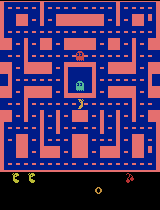

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 351/500 | 206,500 decisions | 51,376 updates | 13.5 min
Episode 351/500 | score 160 | recent mean 650.8 | exploration 20% | learning rate 0.00006400
  Episode 352/500 | 207,000 decisions | 51,501 updates | 13.6 min
Episode 352/500 | score 390 | recent mean 608.4 | exploration 20% | learning rate 0.00006400
  Episode 353/500 | 207,500 decisions | 51,626 updates | 13.6 min
Episode 353/500 | score 1080 | recent mean 620.8 | exploration 20% | learning rate 0.00006400
  Episode 354/500 | 208,000 decisions | 51,751 updates | 13.6 min
Episode 354/500 | score 730 | recent mean 642.8 | exploration 20% | learning rate 0.00006400
  Episode 355/500 | 208,500 decisions | 51,876 updates | 13.7 min
Episode 355/500 | score 360 | recent mean 628.4 | exploration 20% | learning rate 0.00006400
  Episode 356/500 | 209,000 decisions | 52,001 updates | 13.7 min
Episode 356/500 | score 330 | recent mean 621.2 

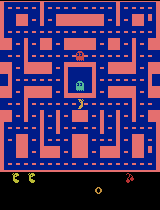

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 376/500 | 221,500 decisions | 55,126 updates | 14.5 min
Episode 376/500 | score 410 | recent mean 690.0 | exploration 20% | learning rate 0.00005120
  Episode 377/500 | 222,000 decisions | 55,251 updates | 14.5 min
  Episode 377/500 | 222,500 decisions | 55,376 updates | 14.6 min
Episode 377/500 | score 930 | recent mean 711.6 | exploration 20% | learning rate 0.00005120
  Episode 378/500 | 223,000 decisions | 55,501 updates | 14.6 min
Episode 378/500 | score 1050 | recent mean 710.4 | exploration 20% | learning rate 0.00005120
  Episode 379/500 | 223,500 decisions | 55,626 updates | 14.6 min
Episode 379/500 | score 280 | recent mean 692.4 | exploration 20% | learning rate 0.00005120
  Episode 380/500 | 224,000 decisions | 55,751 updates | 14.7 min
Episode 380/500 | score 410 | recent mean 694.4 | exploration 20% | learning rate 0.00005120
  Episode 381/500 | 224,500 decisions | 55,876 u

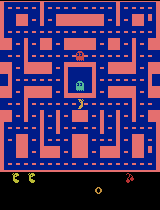

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 401/500 | 235,000 decisions | 58,501 updates | 15.4 min
Episode 401/500 | score 680 | recent mean 609.6 | exploration 20% | learning rate 0.00005120
  Episode 402/500 | 235,500 decisions | 58,626 updates | 15.4 min
Episode 402/500 | score 500 | recent mean 592.4 | exploration 20% | learning rate 0.00005120
  Episode 403/500 | 236,000 decisions | 58,751 updates | 15.5 min
  Episode 403/500 | 236,500 decisions | 58,876 updates | 15.5 min
Episode 403/500 | score 590 | recent mean 574.0 | exploration 20% | learning rate 0.00005120
  Episode 404/500 | 237,000 decisions | 59,001 updates | 15.5 min
Episode 404/500 | score 430 | recent mean 580.0 | exploration 20% | learning rate 0.00005120
  Episode 405/500 | 237,500 decisions | 59,126 updates | 15.6 min
Episode 405/500 | score 490 | recent mean 583.2 | exploration 20% | learning rate 0.00005120
  Episode 406/500 | 238,000 decisions | 59,251 up

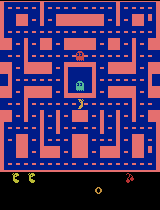

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 426/500 | 250,500 decisions | 62,376 updates | 16.4 min
Episode 426/500 | score 450 | recent mean 674.0 | exploration 20% | learning rate 0.00005120
  Episode 427/500 | 251,000 decisions | 62,501 updates | 16.5 min
  Episode 427/500 | 251,500 decisions | 62,626 updates | 16.5 min
Episode 427/500 | score 720 | recent mean 682.8 | exploration 20% | learning rate 0.00005120
  Episode 428/500 | 252,000 decisions | 62,751 updates | 16.5 min
Episode 428/500 | score 420 | recent mean 676.0 | exploration 20% | learning rate 0.00005120
  Episode 429/500 | 252,500 decisions | 62,876 updates | 16.6 min
Episode 429/500 | score 1180 | recent mean 706.0 | exploration 20% | learning rate 0.00005120
  Episode 430/500 | 253,000 decisions | 63,001 updates | 16.6 min
Episode 430/500 | score 480 | recent mean 705.6 | exploration 20% | learning rate 0.00005120
  Episode 431/500 | 253,500 decisions | 63,126 u

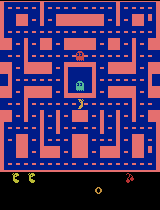

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
Episode 451/500 | score 290 | recent mean 596.0 | exploration 20% | learning rate 0.00005120
  Episode 452/500 | 265,500 decisions | 66,126 updates | 17.4 min
  Episode 452/500 | 266,000 decisions | 66,251 updates | 17.4 min
Episode 452/500 | score 1800 | recent mean 639.2 | exploration 20% | learning rate 0.00005120
  Episode 453/500 | 266,500 decisions | 66,376 updates | 17.5 min
Episode 453/500 | score 230 | recent mean 631.6 | exploration 20% | learning rate 0.00005120
  Episode 454/500 | 267,000 decisions | 66,501 updates | 17.5 min
Episode 454/500 | score 670 | recent mean 611.2 | exploration 20% | learning rate 0.00005120
  Episode 455/500 | 267,500 decisions | 66,626 updates | 17.5 min
Episode 455/500 | score 540 | recent mean 613.6 | exploration 20% | learning rate 0.00005120
  Episode 456/500 | 268,000 decisions | 66,751 updates | 17.6 min
Episode 456/500 | score 370 | recent mean 605.6 

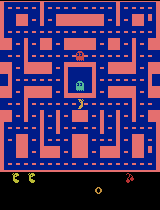

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
  Episode 476/500 | 278,000 decisions | 69,251 updates | 18.2 min
Episode 476/500 | score 320 | recent mean 588.4 | exploration 20% | learning rate 0.00005120
  Episode 477/500 | 278,500 decisions | 69,376 updates | 18.3 min
Episode 477/500 | score 1260 | recent mean 566.8 | exploration 20% | learning rate 0.00005120
  Episode 478/500 | 279,000 decisions | 69,501 updates | 18.3 min
Episode 478/500 | score 760 | recent mean 588.0 | exploration 20% | learning rate 0.00005120
  Episode 479/500 | 279,500 decisions | 69,626 updates | 18.3 min
Episode 479/500 | score 430 | recent mean 578.4 | exploration 20% | learning rate 0.00005120
  Episode 480/500 | 280,000 decisions | 69,751 updates | 18.4 min
Episode 480/500 | score 430 | recent mean 574.0 | exploration 20% | learning rate 0.00005120
  Episode 481/500 | 280,500 decisions | 69,876 updates | 18.4 min
Episode 481/500 | score 800 | recent mean 591.2 

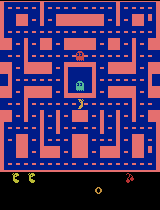

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'
Saved: pacman_runs/20260918_160133_643037


In [ ]:
if _training_started:
    raise RuntimeError("Start a new experiment by rerunning from section 5a, or use Run All.")
_training_started = True
train_env = make_env()
started = time.monotonic()
status = "completed"
try:
    for episode in range(1, EPISODES + 1):
        row = train_one_episode(train_env, episode)
        history.append(row)
        completed_episodes = episode
        recent_mean = np.mean([game["score"] for game in history[-25:]])
        print(f"Episode {episode}/{EPISODES} | score {row['score']:.0f} | "
              f"recent mean {recent_mean:.1f} | exploration {row['exploration']:.0%} | "
              f"learning rate {row['learning_rate']:.8f}", flush=True)
        save_metrics(history, RUN_DIR / "training.csv")
        if episode % DEMO_EVERY == 0:
            save_progress_sample(episode)
except KeyboardInterrupt:
    status = "interrupted"
    print("Stopped early. Saving your agent; continue to section 6 for results.")
except Exception:
    status = "failed"
    raise
finally:
    train_env.close()
    save_training_result(status)
print("Saved:", RUN_DIR)
if updates == 0:
    print("No learning updates yet: this run ended before a training batch was ready.")

## 6. did it learn?

Compare all five games under the same settings. The highlighted GIF is the best of these five trained games;
it is an illustration, not the evidence by itself. Five games give a small comparison, not a reliable research estimate.

### 6a. play the saved agent

Reload the checkpoint and play the same five evaluation seeds. This tests both the saved file and the agent’s behavior.

In [ ]:
# Load the saved model so the evaluation also verifies checkpoint playback.
checkpoint = torch.load(RUN_DIR / "trained.pt", map_location="cpu", weights_only=True)
trained_model = DQN(checkpoint["n_actions"]).to(DEVICE)
trained_model.load_state_dict(checkpoint["model"])
print("Evaluating the saved trained network on the same five games...", flush=True)
after = evaluate(trained_model, EVAL_SEEDS, RUN_DIR / "demos" / "final_best.gif", record_best=True)
print("Evaluating the saved network on supplemental seeds...", flush=True)
supplemental_after = evaluate(trained_model, SUPPLEMENTAL_EVAL_SEEDS)


Evaluating the saved trained network on the same five games...
Evaluating the saved network on supplemental seeds...


### 6b. compare all five scores

Positive change means a higher average in this small test. A short run can get worse, and one good-looking sample is not enough to claim improvement.

  Game     Before      After
     1        200        430
     2        240        580
     3        240        510
     4        240        480
     5        170        250
  Mean      218.0      450.0
Change in mean score: +232.0
Time-limited games before / after: 0 / 0


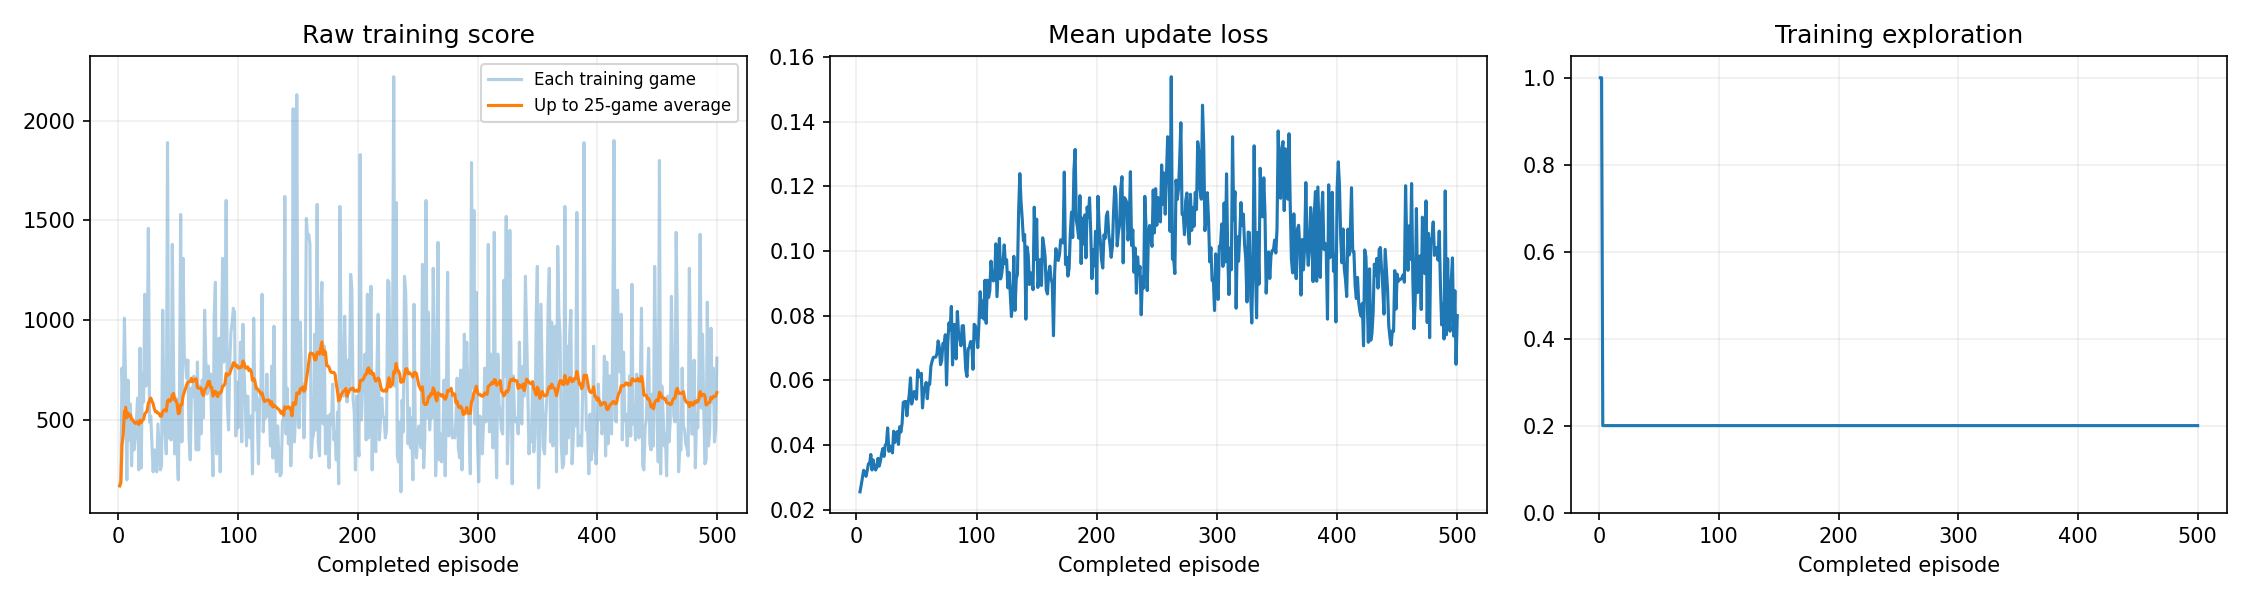

Final saved agent | 4× playback | 2 plays | first 20s of game time


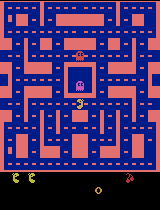

Using the inline preview. Local popup helper unavailable: No module named 'pacman_player'

SUPPLEMENTAL EVALUATION (separate from the official five-game score)
  Seed     Before      After
   606        240        910
   707        230        420
   808        300        830
   909        240        370
  1010        250       1900
  Mean      252.0      886.0
Supplemental time-limited games before / after: 0 / 0


In [ ]:
comparison = {"baseline_kind": "untrained network", "before": baseline, "after": after,
              "evaluation_exploration": EVAL_EXPLORATION, "max_decisions_per_game": MAX_STEPS}
(RUN_DIR / "comparison.json").write_text(json.dumps(comparison, indent=2))
print(f"{'Game':>6} {'Before':>10} {'After':>10}")
for game, (before_score, after_score) in enumerate(zip(baseline["scores"], after["scores"]), 1):
    print(f"{game:>6} {before_score:>10.0f} {after_score:>10.0f}")
print(f"{'Mean':>6} {baseline['mean']:>10.1f} {after['mean']:>10.1f}")
print(f"Change in mean score: {after['mean'] - baseline['mean']:+.1f}")
print("Time-limited games before / after:", sum(baseline["time_limited"]), "/", sum(after["time_limited"]))
display(Image(filename=str(RUN_DIR / "training_dashboard.png")))
show_sample(RUN_DIR / "demos" / "final_best.gif", "Final saved agent")
supplemental_comparison = {
    "baseline_kind": "untrained network", "evaluation_set": "supplemental",
    "before": supplemental_baseline, "after": supplemental_after,
    "evaluation_exploration": EVAL_EXPLORATION, "max_decisions_per_game": MAX_STEPS
}
(RUN_DIR / "supplemental_comparison.json").write_text(json.dumps(supplemental_comparison, indent=2))
print("\nSUPPLEMENTAL EVALUATION (separate from the official five-game score)")
print(f"{'Seed':>6} {'Before':>10} {'After':>10}")
for seed, before_score, after_score in zip(SUPPLEMENTAL_EVAL_SEEDS, supplemental_baseline["scores"], supplemental_after["scores"]):
    print(f"{seed:>6} {before_score:>10.0f} {after_score:>10.0f}")
print(f"{'Mean':>6} {supplemental_baseline['mean']:>10.1f} {supplemental_after['mean']:>10.1f}")
print("Supplemental time-limited games before / after:", sum(supplemental_baseline["time_limited"]), "/", sum(supplemental_after["time_limited"]))


## 7. save and explain your experiment

The next cell creates a ZIP containing your settings, package versions, all evaluation scores, training log,
plot, GIFs, and playback checkpoints. In Colab, download it before ending the session.
To try another setting, change the three choices and run all cells again; that starts from scratch.

Keep the notebook, plot, selected GIFs, comparison, and your explanation in your GitHub submission.
Model checkpoints can make repositories large; keep them locally or attach them to a GitHub release.

In [ ]:
archive = shutil.make_archive(str(RUN_DIR), "zip", root_dir=RUN_DIR)
try:
    from google.colab import files
except ImportError:
    display(FileLink(archive, result_html_prefix="Download your experiment: "))
else:
    files.download(archive)
print("Results folder:", RUN_DIR.resolve())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Results folder: /content/pacman_runs/20260918_160133_643037


### your explanation

**Choices recorded before running:** exploration 0.20; 500 fresh training episodes;
initial learning rate 0.0001, multiplied by 0.8 after 125, 250, and 375 completed
episodes; training seed 31415. The original five evaluation seeds remain the
main comparison. Supplemental seeds are 606, 707, 808, 909, and 1010, each tested
both before and after training.

**Prediction:** More experience and smaller later updates may improve pellet
collection and reduce unstable updates, but improvement is uncertain. The
200-episode experiment underperformed the 50-episode experiment. This follow-up
changes the budget, training seed, and learning-rate schedule together, so its
outcome cannot identify the contribution of any one change.

**Completed results:** 500 fresh episodes, 292,152 decisions, and 72,789 learning updates
on a Colab T4 / CUDA, with 1,150.27 seconds (19.17 minutes) of training including periodic demos.
The learning rate followed the specified four blocks and ended at 0.0000512.

| Official evaluation seed | Untrained | Trained |
|---|---:|---:|
| 101 | 200 | 430 |
| 202 | 240 | 580 |
| 303 | 240 | 510 |
| 404 | 240 | 480 |
| 505 | 170 | 250 |
| **Mean** | **218** | **450** |

Every official game improved from its own baseline, with no time-limit endings. The final
median was 480. The mean remained below the earlier fresh 50-episode mean of 800 and
200-episode mean of 534. The follow-up improved relative to its own baseline, but this
multi-change experiment cannot establish whether more experience or smaller later updates helped.
Those earlier runs used seed 42 and a constant learning rate, so this is not an isolated
comparison of episode budgets.

Supplemental seeds 606, 707, 808, 909, and 1010 scored **240, 230, 300, 240, 250** before
and **910, 420, 830, 370, 1900** after training: means **252 and 886**, respectively.
No supplemental game hit the time limit. All improved, but the 1900-point game raises
the mean. These scores remain separate; the official classroom mean is **450**.

**Learning and behavior:** Four consecutive 84 × 84 grayscale screens are the observations;
joystick moves are the actions, and game points supply the reward. Rewards are clipped to
[-1, 1] for learning; reported scores retain raw game points. First/final 25-game training
means were 584.0 and 637.6, and the rolling average peaked earlier. Lower loss does not
by itself establish better play.

All 22 GIFs were inspected through sampled frames. On matched seed 101, the trained
excerpt reached 320 versus the baseline's 170 (full games: 430 versus 200), collecting
pellets through more lower and right-side passages. It still backtracked through a
cleared passage and lost a life; both excerpts showed life loss. The best final official
game was seed 202: excerpt 450, complete game 580. It is selected from five games and is
not a matched comparison. The GIFs show only the opening portion of each game.

**Limitation and next experiment:** Navigation remains inefficient and periodic scores
vary substantially; seed 101 scored 1650 at episode 425 but 430 at episode 500. One run
per configuration and two small evaluation sets cannot establish a general ranking.
Change only the decay factor from 0.8 to 1.0 next, keeping 500 episodes, seed 31415,
exploration 0.20, and evaluation settings fixed, to compare this schedule with a constant
0.0001 learning rate. That proposed experiment has not been run.

**Saved evidence and confidence:** The full ZIP `20260918_160133_643037.zip` is retained
locally with 22 playback checkpoints. The README embeds all gameplay GIFs and the plot,
links the logs/configuration, and compares all three runs. Confidence is high in the saved
scores and arithmetic, and low in a general causal explanation. Colab's downloaded export
retained all 59 outputs but omitted execution counters; counters were not reconstructed.
The local audit reconciled all 500 printed training rows and final tables with the ZIP,
and confirmed that all 28 code-cell sources exactly match the prepared notebook. This
submission copy changes only this explanatory markdown cell; it preserves code and outputs.

### Gameplay gallery for GitHub preview

GitHub's notebook renderer displays text placeholders for the original `image/gif` outputs. This gallery displays the same saved GIF files from the public repository. The original code, GIF output data, and all other outputs are retained unchanged. This is a viewing aid added after the experiment, not a new evaluation. Each clip shows at most the opening 20 seconds of game time at faster playback.

**Untrained — seed 101**

![Untrained — seed 101](https://raw.githubusercontent.com/shahdevansh/pacman-dqn-class3/d0752967cdbc4f3211d87401a990c6dcdf01b842/results/run_500/demos/episode_0000.gif)

**After 25 training episodes — seed 101**

![After 25 training episodes — seed 101](https://raw.githubusercontent.com/shahdevansh/pacman-dqn-class3/d0752967cdbc4f3211d87401a990c6dcdf01b842/results/run_500/demos/episode_0025.gif)

**After 50 training episodes — seed 101**

![After 50 training episodes — seed 101](https://raw.githubusercontent.com/shahdevansh/pacman-dqn-class3/d0752967cdbc4f3211d87401a990c6dcdf01b842/results/run_500/demos/episode_0050.gif)

**After 75 training episodes — seed 101**

![After 75 training episodes — seed 101](https://raw.githubusercontent.com/shahdevansh/pacman-dqn-class3/d0752967cdbc4f3211d87401a990c6dcdf01b842/results/run_500/demos/episode_0075.gif)

**After 100 training episodes — seed 101**

![After 100 training episodes — seed 101](https://raw.githubusercontent.com/shahdevansh/pacman-dqn-class3/d0752967cdbc4f3211d87401a990c6dcdf01b842/results/run_500/demos/episode_0100.gif)

**After 125 training episodes — seed 101**

![After 125 training episodes — seed 101](https://raw.githubusercontent.com/shahdevansh/pacman-dqn-class3/d0752967cdbc4f3211d87401a990c6dcdf01b842/results/run_500/demos/episode_0125.gif)

**After 150 training episodes — seed 101**

![After 150 training episodes — seed 101](https://raw.githubusercontent.com/shahdevansh/pacman-dqn-class3/d0752967cdbc4f3211d87401a990c6dcdf01b842/results/run_500/demos/episode_0150.gif)

**After 175 training episodes — seed 101**

![After 175 training episodes — seed 101](https://raw.githubusercontent.com/shahdevansh/pacman-dqn-class3/d0752967cdbc4f3211d87401a990c6dcdf01b842/results/run_500/demos/episode_0175.gif)

**After 200 training episodes — seed 101**

![After 200 training episodes — seed 101](https://raw.githubusercontent.com/shahdevansh/pacman-dqn-class3/d0752967cdbc4f3211d87401a990c6dcdf01b842/results/run_500/demos/episode_0200.gif)

**After 225 training episodes — seed 101**

![After 225 training episodes — seed 101](https://raw.githubusercontent.com/shahdevansh/pacman-dqn-class3/d0752967cdbc4f3211d87401a990c6dcdf01b842/results/run_500/demos/episode_0225.gif)

**After 250 training episodes — seed 101**

![After 250 training episodes — seed 101](https://raw.githubusercontent.com/shahdevansh/pacman-dqn-class3/d0752967cdbc4f3211d87401a990c6dcdf01b842/results/run_500/demos/episode_0250.gif)

**After 275 training episodes — seed 101**

![After 275 training episodes — seed 101](https://raw.githubusercontent.com/shahdevansh/pacman-dqn-class3/d0752967cdbc4f3211d87401a990c6dcdf01b842/results/run_500/demos/episode_0275.gif)

**After 300 training episodes — seed 101**

![After 300 training episodes — seed 101](https://raw.githubusercontent.com/shahdevansh/pacman-dqn-class3/d0752967cdbc4f3211d87401a990c6dcdf01b842/results/run_500/demos/episode_0300.gif)

**After 325 training episodes — seed 101**

![After 325 training episodes — seed 101](https://raw.githubusercontent.com/shahdevansh/pacman-dqn-class3/d0752967cdbc4f3211d87401a990c6dcdf01b842/results/run_500/demos/episode_0325.gif)

**After 350 training episodes — seed 101**

![After 350 training episodes — seed 101](https://raw.githubusercontent.com/shahdevansh/pacman-dqn-class3/d0752967cdbc4f3211d87401a990c6dcdf01b842/results/run_500/demos/episode_0350.gif)

**After 375 training episodes — seed 101**

![After 375 training episodes — seed 101](https://raw.githubusercontent.com/shahdevansh/pacman-dqn-class3/d0752967cdbc4f3211d87401a990c6dcdf01b842/results/run_500/demos/episode_0375.gif)

**After 400 training episodes — seed 101**

![After 400 training episodes — seed 101](https://raw.githubusercontent.com/shahdevansh/pacman-dqn-class3/d0752967cdbc4f3211d87401a990c6dcdf01b842/results/run_500/demos/episode_0400.gif)

**After 425 training episodes — seed 101**

![After 425 training episodes — seed 101](https://raw.githubusercontent.com/shahdevansh/pacman-dqn-class3/d0752967cdbc4f3211d87401a990c6dcdf01b842/results/run_500/demos/episode_0425.gif)

**After 450 training episodes — seed 101**

![After 450 training episodes — seed 101](https://raw.githubusercontent.com/shahdevansh/pacman-dqn-class3/d0752967cdbc4f3211d87401a990c6dcdf01b842/results/run_500/demos/episode_0450.gif)

**After 475 training episodes — seed 101**

![After 475 training episodes — seed 101](https://raw.githubusercontent.com/shahdevansh/pacman-dqn-class3/d0752967cdbc4f3211d87401a990c6dcdf01b842/results/run_500/demos/episode_0475.gif)

**After 500 training episodes — seed 101**

![After 500 training episodes — seed 101](https://raw.githubusercontent.com/shahdevansh/pacman-dqn-class3/d0752967cdbc4f3211d87401a990c6dcdf01b842/results/run_500/demos/episode_0500.gif)

**Best final official game — seed 202, full-game score 580**

![Best final official gameplay, seed 202](https://raw.githubusercontent.com/shahdevansh/pacman-dqn-class3/d0752967cdbc4f3211d87401a990c6dcdf01b842/results/run_500/demos/final_best.gif)

### implementation notes and sources

This is a small, readable DQN experiment, not a reproduction of a large Atari benchmark.
Replay is deliberately small for laptops. Epsilon stays constant after warm-up. Checkpoints support playback;
rerunning starts a new experiment, rather than resuming the optimizer, replay memory, or an interrupted game.
GPU results can vary even with fixed seeds.

- [ALE installation and Gymnasium registration](https://ale.farama.org/getting-started/)
- [Gymnasium Atari preprocessing](https://gymnasium.farama.org/api/wrappers/misc_wrappers/#gymnasium.wrappers.AtariPreprocessing)
- [Gymnasium frame stacking](https://gymnasium.farama.org/api/wrappers/observation_wrappers/#gymnasium.wrappers.FrameStackObservation)
- [DQN paper: Human-level control through deep reinforcement learning](https://storage.googleapis.com/deepmind-media/dqn/DQNNaturePaper.pdf)